In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("Libraries imported successfully")

Libraries imported successfully


In [13]:
df = pd.read_csv("C:/Users/SHARVARI/Downloads/Retail_Profit_Leakage_Project/Data/Processed/final_retail_dataset.csv")

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully
Rows: 51290
Columns: 49


In [14]:
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['category', 'city', 'country', 'customer_id', 'customer_name', 'discount', 'market', 'order_date', 'order_id', 'order_priority', 'product_id', 'product_name', 'profit', 'quantity', 'region', 'row_id', 'sales', 'segment', 'ship_date', 'ship_mode', 'shipping_cost', 'state', 'sub_category', 'year', 'market2', 'weeknum', 'delivery_days', 'profit_margin', 'month', 'month_no', 'quarter', 'day', 'week', 'is_weekend', 'discount_band', 'loss_order', 'high_discount', 'sales_bucket', 'profit_bucket', 'shipping_cost_bucket', 'average_order_value', 'shipping_cost_pct', 'discount_amount', 'net_sales', 'profit_status', 'delivery_status', 'profit_per_unit', 'inflation_rate', 'gdp_growth']


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   category              51290 non-null  object 
 1   city                  51290 non-null  object 
 2   country               51290 non-null  object 
 3   customer_id           51290 non-null  object 
 4   customer_name         51290 non-null  object 
 5   discount              51290 non-null  float64
 6   market                51290 non-null  object 
 7   order_date            51290 non-null  object 
 8   order_id              51290 non-null  object 
 9   order_priority        51290 non-null  object 
 10  product_id            51290 non-null  object 
 11  product_name          51290 non-null  object 
 12  profit                51290 non-null  float64
 13  quantity              51290 non-null  int64  
 14  region                51290 non-null  object 
 15  row_id             

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
discount,51290.0,0.142908,0.212280,0.000000,0.000000,0.000000,0.200000,0.850000
profit,51290.0,28.610982,174.340972,-6599.978000,0.000000,9.240000,36.810000,8399.976000
quantity,51290.0,3.476545,2.278766,1.000000,2.000000,3.000000,5.000000,14.000000
row_id,51290.0,25645.500000,14806.291990,1.000000,12823.250000,25645.500000,38467.750000,51290.000000
sales,51290.0,246.498440,487.567175,0.000000,31.000000,85.000000,251.000000,22638.000000
shipping_cost,51290.0,26.375818,57.296810,0.002000,2.610000,7.790000,24.450000,933.570000
year,51290.0,2012.777208,1.098931,2011.000000,2012.000000,2013.000000,2014.000000,2014.000000
weeknum,51290.0,31.287112,14.429795,1.000000,20.000000,33.000000,44.000000,53.000000
delivery_days,51290.0,3.969370,1.729437,0.000000,3.000000,4.000000,5.000000,7.000000
profit_margin,51290.0,4.719877,46.684489,-472.775207,0.000000,16.924859,33.311107,58.280000


In [17]:
missing = df.isnull().sum()

print("Missing values:")
print(missing[missing > 0])

Missing values:
inflation_rate    1299
gdp_growth         172
dtype: int64


In [18]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [19]:
print(df.dtypes)

category                 object
city                     object
country                  object
customer_id              object
customer_name            object
discount                float64
market                   object
order_date               object
order_id                 object
order_priority           object
product_id               object
product_name             object
profit                  float64
quantity                  int64
region                   object
row_id                    int64
sales                     int64
segment                  object
ship_date                object
ship_mode                object
shipping_cost           float64
state                    object
sub_category             object
year                      int64
market2                  object
weeknum                   int64
delivery_days             int64
profit_margin           float64
month                    object
month_no                  int64
quarter                   int64
day     

In [20]:
key_stats = df[
    [
        "sales",
        "profit",
        "discount",
        "profit_margin",
        "quantity",
        "shipping_cost",
        "delivery_days",
        "average_order_value"
    ]
].describe().T

key_stats

,count,mean,std,min,25%,50%,75%,max
sales,51290.0,246.498440,487.567175,0.000000,31.00,85.000000,251.000000,22638.000
profit,51290.0,28.610982,174.340972,-6599.978000,0.00,9.240000,36.810000,8399.976
discount,51290.0,0.142908,0.212280,0.000000,0.00,0.000000,0.200000,0.850
profit_margin,51290.0,4.719877,46.684489,-472.775207,0.00,16.924859,33.311107,58.280
quantity,51290.0,3.476545,2.278766,1.000000,2.00,3.000000,5.000000,14.000
shipping_cost,51290.0,26.375818,57.296810,0.002000,2.61,7.790000,24.450000,933.570
delivery_days,51290.0,3.969370,1.729437,0.000000,3.00,4.000000,5.000000,7.000
average_order_value,51290.0,71.659964,113.581076,0.000000,12.00,29.500000,82.000000,3773.000


In [21]:
median_values = df[
    [
        "sales",
        "profit",
        "discount",
        "profit_margin",
        "quantity",
        "shipping_cost",
        "delivery_days",
        "average_order_value"
    ]
].median()

median_values

sales                  85.000000
profit                  9.240000
discount                0.000000
profit_margin          16.924859
quantity                3.000000
shipping_cost           7.790000
delivery_days           4.000000
average_order_value    29.500000
dtype: float64

In [22]:
std_values = df[
    [
        "sales",
        "profit",
        "discount",
        "profit_margin",
        "quantity",
        "shipping_cost",
        "delivery_days",
        "average_order_value"
    ]
].std()

std_values

sales                  487.567175
profit                 174.340972
discount                 0.212280
profit_margin           46.684489
quantity                 2.278766
shipping_cost           57.296810
delivery_days            1.729437
average_order_value    113.581076
dtype: float64

In [23]:
quartiles = df[
    [
        "sales",
        "profit",
        "discount",
        "profit_margin",
        "average_order_value"
    ]
].quantile([0.25, 0.50, 0.75])

quartiles

,sales,profit,discount,profit_margin,average_order_value
0.25,31.0,0.00,0.0,0.000000,12.0
0.50,85.0,9.24,0.0,16.924859,29.5
0.75,251.0,36.81,0.2,33.311107,82.0


In [24]:
print("Profit:")
print("Minimum:", df["profit"].min())
print("Maximum:", df["profit"].max())

print("\nDiscount:")
print("Minimum:", df["discount"].min())
print("Maximum:", df["discount"].max())

print("\nProfit Margin:")
print("Minimum:", df["profit_margin"].min())
print("Maximum:", df["profit_margin"].max())

Profit:
Minimum: -6599.978
Maximum: 8399.976

Discount:
Minimum: 0.0
Maximum: 0.85

Profit Margin:
Minimum: -472.7752066
Maximum: 58.28


In [25]:
numeric_cols = [
    "sales",
    "profit",
    "discount",
    "profit_margin",
    "average_order_value"
]

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": len(outliers)
    }

outlier_summary_df = pd.DataFrame(outlier_summary).T
outlier_summary_df

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
sales,31.0,251.000000,220.000000,-299.00000,581.000000,5655.0
profit,0.0,36.810000,36.810000,-55.21500,92.025000,9755.0
discount,0.0,0.200000,0.200000,-0.30000,0.500000,4172.0
profit_margin,0.0,33.311107,33.311107,-49.96666,83.277767,5648.0
average_order_value,12.0,82.000000,70.000000,-93.00000,187.000000,5023.0


In [26]:
outlier_summary_df["Outlier %"] = (
    outlier_summary_df["Outlier Count"] / len(df) * 100
)

outlier_summary_df[["Outlier Count", "Outlier %"]]

,Outlier Count,Outlier %
sales,5655.0,11.025541
profit,9755.0,19.019302
discount,4172.0,8.134139
profit_margin,5648.0,11.011893
average_order_value,5023.0,9.793332


In [27]:
loss_orders = df.sort_values(
    by="profit",
    ascending=True
)

loss_orders[
    [
        "order_id",
        "customer_name",
        "product_name",
        "country",
        "discount",
        "sales",
        "profit",
        "profit_margin"
    ]
].head(10)

,order_id,customer_name,product_name,country,discount,sales,profit,profit_margin
47074,CA-2013-108196,Cindy Stewart,Cubify CubeX 3D Printer Double Head Print,United States,0.7,4500,-6599.9780,-146.666178
29353,TU-2013-9400,Denise Monton,"Motorola Smart Phone, Cordless",Turkiye,0.6,3085,-4088.3760,-132.524344
47388,US-2014-168116,Grant Thornton,Cubify CubeX 3D Printer Triple Head Print,United States,0.5,8000,-3839.9904,-47.999880
46422,CA-2011-169019,Luke Foster,GBC DocuBind P400 Electric Binding System,United States,0.8,2178,-3701.8928,-169.967530
47414,CA-2014-134845,Sharelle Roach,Lexmark MX611dhe Monochrome Laser Printer,United States,0.7,2550,-3399.9800,-133.332549
39499,IT-2013-3695467,Saphhira Shifley,"Hoover Stove, White",Portugal,0.5,3400,-3059.8200,-89.994706
30168,ID-2013-12295,Skye Norling,"Apple Smart Phone, Full Size",Pakistan,0.5,3499,-3009.4350,-86.008431
46876,US-2014-122714,Henry Goldwyn,Ibico EPK-21 Electric Binding System,United States,0.8,1890,-2929.4845,-154.999180
29652,LH-2014-5390,Julie Creighton,"Barricks Conference Table, Rectangular",Lithuania,0.7,2171,-2750.2800,-126.682635
47070,CA-2012-147830,Natalie Fritzler,Cubify CubeX 3D Printer Double Head Print,United States,0.7,1800,-2639.9912,-146.666178


In [28]:
loss_count = (df["profit"] < 0).sum()
loss_percentage = loss_count / len(df) * 100

print("Loss-making orders:", loss_count)
print("Percentage of loss-making orders:", round(loss_percentage, 2), "%")

Loss-making orders: 12544
Percentage of loss-making orders: 24.46 %


In [29]:
high_discount_loss = df[
    (df["discount"] > 0.30) &
    (df["profit"] < 0)
]

print("High-discount loss-making orders:", len(high_discount_loss))
print(
    "Percentage of all loss-making orders:",
    round(len(high_discount_loss) / loss_count * 100, 2),
    "%"
)

High-discount loss-making orders: 9579
Percentage of all loss-making orders: 76.36 %


In [31]:
discount_profit_corr = df["discount"].corr(df["profit_margin"])

print(
    "Correlation between Discount and Profit Margin:",
    round(discount_profit_corr, 4)
)

Correlation between Discount and Profit Margin: -0.8464


In [33]:
r, p_value = stats.pearsonr(
    df["discount"],
    df["profit_margin"]
)

print("Pearson correlation:", round(r, 4))
print("P-value:", p_value)

Pearson correlation: -0.8464
P-value: 0.0


In [34]:
alpha = 0.05

if p_value < alpha:
    print("Result: Statistically significant relationship.")
else:
    print("Result: No statistically significant relationship.")

if r < 0:
    print("Direction: Negative relationship.")
elif r > 0:
    print("Direction: Positive relationship.")
else:
    print("Direction: No linear relationship.")

Result: Statistically significant relationship.
Direction: Negative relationship.


In [35]:
spearman_r, spearman_p = stats.spearmanr(
    df["discount"],
    df["profit_margin"]
)

print("Spearman correlation:", round(spearman_r, 4))
print("P-value:", spearman_p)

Spearman correlation: -0.669
P-value: 0.0


In [36]:
print(df["discount_band"].value_counts())

discount_band
No Discount    29009
10-20%          6274
30-50%          6189
0-10%           4679
Above 50%       4172
20-30%           967
Name: count, dtype: int64


In [37]:
discount_summary = (
    df.groupby("discount_band")["profit_margin"]
    .agg(["count", "mean", "median", "std"])
    .round(4)
)

discount_summary

,count,mean,median,std
discount_band,,,,
0-10%,4679,17.1330,16.8285,16.1718
10-20%,6274,13.7621,12.4904,18.0193
20-30%,967,-3.8533,-4.2850,18.7297
30-50%,6189,-33.7888,-33.1475,28.0336
Above 50%,4172,-115.0090,-106.5715,55.5405
No Discount,29009,26.4827,27.0000,14.8827


In [38]:
groups = [
    group["profit_margin"].dropna()
    for _, group in df.groupby("discount_band")
]

print("Number of groups:", len(groups))
print("Group sizes:", [len(g) for g in groups])

Number of groups: 6
Group sizes: [4679, 6274, 967, 6189, 4172, 29009]


In [39]:
f_stat, anova_p = stats.f_oneway(*groups)

print("F-statistic:", round(f_stat, 4))
print("P-value:", anova_p)

F-statistic: 31053.5898
P-value: 0.0


In [40]:
alpha = 0.05

if anova_p < alpha:
    print("Reject H0.")
    print("Profit margin differs significantly across discount bands.")
else:
    print("Fail to reject H0.")
    print("There is not enough evidence that profit margin differs across discount bands.")

Reject H0.
Profit margin differs significantly across discount bands.


In [41]:
tukey = pairwise_tukeyhsd(
    endog=df["profit_margin"],
    groups=df["discount_band"],
    alpha=0.05
)

print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
  group1     group2    meandiff p-adj   lower     upper   reject
----------------------------------------------------------------
    0-10%      10-20%   -3.3709   0.0   -4.6514   -2.0903   True
    0-10%      20-30%  -20.9862   0.0  -23.3281  -18.6444   True
    0-10%      30-50%  -50.9218   0.0  -52.2061  -49.6374   True
    0-10%   Above 50%  -132.142   0.0 -133.5536 -130.7303   True
    0-10% No Discount    9.3497   0.0    8.3052   10.3941   True
   10-20%      20-30%  -17.6154   0.0  -19.9057   -15.325   True
   10-20%      30-50%  -47.5509   0.0  -48.7386  -46.3632   True
   10-20%   Above 50% -128.7711   0.0 -130.0955 -127.4467   True
   10-20% No Discount   12.7205   0.0   11.7975   13.6436   True
   20-30%      30-50%  -29.9355   0.0   -32.228  -27.6431   True
   20-30%   Above 50% -111.1557   0.0 -113.5219 -108.7896   True
   20-30% No Discount   30.3359   0.0   28.1687   32.5031   True
   30-50%   Above 50%  -8

In [42]:
tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)

tukey_df

,group1,group2,meandiff,p-adj,lower,upper,reject
0,0-10%,10-20%,-3.3709,0.0,-4.6514,-2.0903,True
1,0-10%,20-30%,-20.9862,0.0,-23.3281,-18.6444,True
2,0-10%,30-50%,-50.9218,0.0,-52.2061,-49.6374,True
3,0-10%,Above 50%,-132.1420,0.0,-133.5536,-130.7303,True
4,0-10%,No Discount,9.3497,0.0,8.3052,10.3941,True
5,10-20%,20-30%,-17.6154,0.0,-19.9057,-15.3250,True
6,10-20%,30-50%,-47.5509,0.0,-48.7386,-46.3632,True
7,10-20%,Above 50%,-128.7711,0.0,-130.0955,-127.4467,True
8,10-20%,No Discount,12.7205,0.0,11.7975,13.6436,True
9,20-30%,30-50%,-29.9355,0.0,-32.2280,-27.6431,True


In [67]:
tukey_display = tukey_df.copy()

tukey_display["p-adj"] = tukey_display["p-adj"].apply(
    lambda x: "< 0.001" if x < 0.001 else f"{x:.4f}"
)

tukey_display

,group1,group2,meandiff,p-adj,lower,upper,reject
0,0-10%,10-20%,-3.3709,< 0.001,-4.6514,-2.0903,True
1,0-10%,20-30%,-20.9862,< 0.001,-23.3281,-18.6444,True
2,0-10%,30-50%,-50.9218,< 0.001,-52.2061,-49.6374,True
3,0-10%,Above 50%,-132.1420,< 0.001,-133.5536,-130.7303,True
4,0-10%,No Discount,9.3497,< 0.001,8.3052,10.3941,True
5,10-20%,20-30%,-17.6154,< 0.001,-19.9057,-15.3250,True
6,10-20%,30-50%,-47.5509,< 0.001,-48.7386,-46.3632,True
7,10-20%,Above 50%,-128.7711,< 0.001,-130.0955,-127.4467,True
8,10-20%,No Discount,12.7205,< 0.001,11.7975,13.6436,True
9,20-30%,30-50%,-29.9355,< 0.001,-32.2280,-27.6431,True


In [43]:
significant_pairs = tukey_df[
    tukey_df["reject"] == True
]

significant_pairs

,group1,group2,meandiff,p-adj,lower,upper,reject
0,0-10%,10-20%,-3.3709,0.0,-4.6514,-2.0903,True
1,0-10%,20-30%,-20.9862,0.0,-23.3281,-18.6444,True
2,0-10%,30-50%,-50.9218,0.0,-52.2061,-49.6374,True
3,0-10%,Above 50%,-132.1420,0.0,-133.5536,-130.7303,True
4,0-10%,No Discount,9.3497,0.0,8.3052,10.3941,True
5,10-20%,20-30%,-17.6154,0.0,-19.9057,-15.3250,True
6,10-20%,30-50%,-47.5509,0.0,-48.7386,-46.3632,True
7,10-20%,Above 50%,-128.7711,0.0,-130.0955,-127.4467,True
8,10-20%,No Discount,12.7205,0.0,11.7975,13.6436,True
9,20-30%,30-50%,-29.9355,0.0,-32.2280,-27.6431,True


In [44]:
total_comparisons = len(tukey_df)
significant_comparisons = len(significant_pairs)

print("Total pairwise comparisons:", total_comparisons)
print("Significant differences:", significant_comparisons)

Total pairwise comparisons: 15
Significant differences: 15


In [45]:
if anova_p < 0.05:
    print("ANOVA result: Significant.")
    print("There is a statistically significant difference in profit margin across discount bands.")
    print("Tukey HSD identifies which specific discount bands differ.")
else:
    print("ANOVA result: Not significant.")

ANOVA result: Significant.
There is a statistically significant difference in profit margin across discount bands.
Tukey HSD identifies which specific discount bands differ.


In [46]:
from scipy.stats import shapiro

normality_results = []

for band, group in df.groupby("discount_band"):
    sample = group["profit_margin"].dropna()

    # Shapiro is sensitive with very large samples, so use a sample of 5000
    sample_test = sample.sample(
        min(5000, len(sample)),
        random_state=42
    )

    stat, p = shapiro(sample_test)

    normality_results.append({
        "Discount Band": band,
        "Statistic": stat,
        "P-value": p
    })

normality_df = pd.DataFrame(normality_results)
normality_df

,Discount Band,Statistic,P-value
0,0-10%,0.960156,5.034445e-34
1,10-20%,0.934965,3.021960e-42
2,20-30%,0.969650,2.516200e-13
3,30-50%,0.981196,3.046965e-25
4,Above 50%,0.957818,3.617171e-33
5,No Discount,0.953957,4.696931e-37


In [47]:
normality_df["Significant"] = normality_df["P-value"] < 0.05

normality_df

,Discount Band,Statistic,P-value,Significant
0,0-10%,0.960156,5.034445e-34,True
1,10-20%,0.934965,3.021960e-42,True
2,20-30%,0.969650,2.516200e-13,True
3,30-50%,0.981196,3.046965e-25,True
4,Above 50%,0.957818,3.617171e-33,True
5,No Discount,0.953957,4.696931e-37,True


In [48]:
variance_groups = [
    group["profit_margin"].dropna()
    for _, group in df.groupby("discount_band")
]

levene_stat, levene_p = stats.levene(*variance_groups)

print("Levene statistic:", round(levene_stat, 4))
print("P-value:", levene_p)

Levene statistic: 4523.2697
P-value: 0.0


In [49]:
if levene_p < 0.05:
    print("Variances are significantly different.")
    print("ANOVA variance assumption is violated.")
else:
    print("No significant difference in variances.")
    print("Equal variance assumption is reasonable.")

Variances are significantly different.
ANOVA variance assumption is violated.


In [63]:
from statsmodels.stats.oneway import anova_oneway

welch_result = anova_oneway(
    df["profit_margin"],
    groups=df["discount_band"],
    use_var="unequal"
)

print("Welch's ANOVA")
print("-------------------------")
print("Statistic:", round(welch_result.statistic, 4))
print("P-value:", welch_result.pvalue)

Welch's ANOVA
-------------------------
Statistic: 11077.2888
P-value: 0.0


In [50]:
kruskal_stat, kruskal_p = stats.kruskal(*variance_groups)

print("Kruskal-Wallis statistic:", round(kruskal_stat, 4))
print("P-value:", kruskal_p)

Kruskal-Wallis statistic: 26135.6014
P-value: 0.0


In [64]:
if welch_result.pvalue < 0.05:
    print("Result: Statistically significant.")
    print("Profit margin differs significantly across discount bands.")
else:
    print("Result: Not statistically significant.")

Result: Statistically significant.
Profit margin differs significantly across discount bands.


In [65]:
grand_mean = df["profit_margin"].mean()

ss_between = sum(
    len(group) * (group["profit_margin"].mean() - grand_mean) ** 2
    for _, group in df.groupby("discount_band")
)

ss_total = sum(
    (df["profit_margin"] - grand_mean) ** 2
)

eta_squared = ss_between / ss_total

print("Eta Squared:", round(eta_squared, 4))

Eta Squared: 0.7517


In [52]:
if eta_squared < 0.01:
    interpretation = "Very small effect"
elif eta_squared < 0.06:
    interpretation = "Small effect"
elif eta_squared < 0.14:
    interpretation = "Medium effect"
else:
    interpretation = "Large effect"

print("Effect size:", interpretation)

Effect size: Large effect


In [53]:
variance_explained = eta_squared * 100

print(
    "Discount bands explain approximately",
    round(variance_explained, 2),
    "% of the variation in profit margin."
)

Discount bands explain approximately 75.17 % of the variation in profit margin.


In [54]:
mean_profit_margin = (
    df.groupby("discount_band")["profit_margin"]
    .mean()
    .sort_values(ascending=False)
)

print("Most profitable discount band:")
print(mean_profit_margin.head(1))

print("\nLeast profitable discount band:")
print(mean_profit_margin.tail(1))

Most profitable discount band:
discount_band
No Discount    26.482671
Name: profit_margin, dtype: float64

Least profitable discount band:
discount_band
Above 50%   -115.008962
Name: profit_margin, dtype: float64


In [66]:
statistical_summary = pd.DataFrame({
    "Metric": [
        "Pearson Correlation",
        "Pearson P-value",
        "ANOVA F-statistic",
        "ANOVA P-value",
        "Welch ANOVA Statistic",
        "Welch ANOVA P-value",
        "Kruskal-Wallis Statistic",
        "Kruskal-Wallis P-value",
        "Eta Squared"
    ],
    "Value": [
        f"{r:.4f}",
        "< 0.001" if p_value < 0.001 else f"{p_value:.4f}",
        f"{f_stat:.4f}",
        "< 0.001" if anova_p < 0.001 else f"{anova_p:.4f}",
        f"{welch_result.statistic:.4f}",
        "< 0.001" if welch_result.pvalue < 0.001 else f"{welch_result.pvalue:.4f}",
        f"{kruskal_stat:.4f}",
        "< 0.001" if kruskal_p < 0.001 else f"{kruskal_p:.4f}",
        f"{eta_squared:.4f}"
    ]
})

statistical_summary

,Metric,Value
0,Pearson Correlation,-0.8464
1,Pearson P-value,< 0.001
2,ANOVA F-statistic,31053.5898
3,ANOVA P-value,< 0.001
4,Welch ANOVA Statistic,11077.2888
5,Welch ANOVA P-value,< 0.001
6,Kruskal-Wallis Statistic,26135.6014
7,Kruskal-Wallis P-value,< 0.001
8,Eta Squared,0.7517


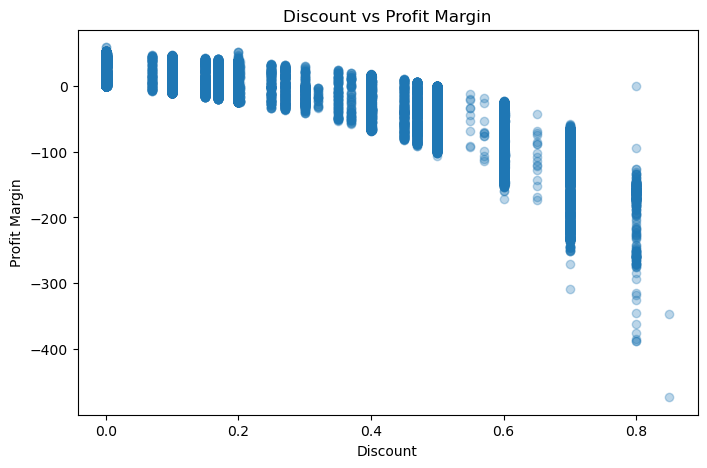

In [56]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["discount"],
    df["profit_margin"],
    alpha=0.3
)

plt.xlabel("Discount")
plt.ylabel("Profit Margin")
plt.title("Discount vs Profit Margin")

plt.show()

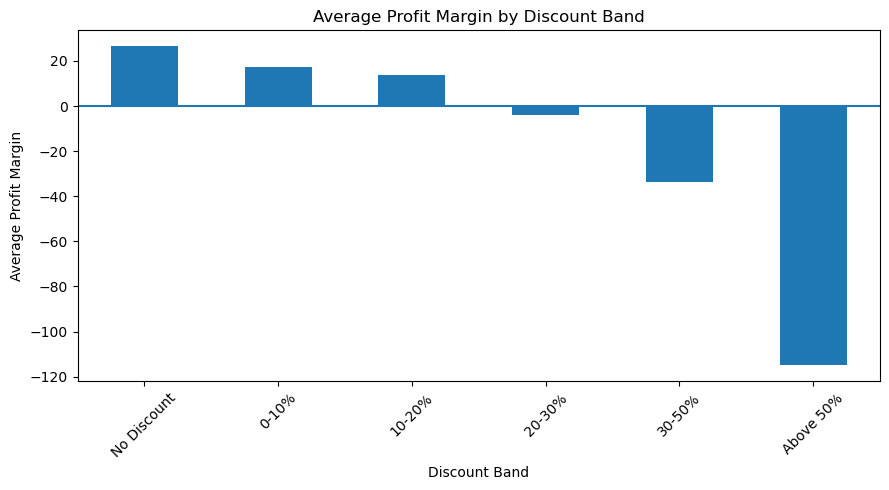

In [57]:
band_order = [
    "No Discount",
    "0-10%",
    "10-20%",
    "20-30%",
    "30-50%",
    "Above 50%"
]

band_profit = (
    df.groupby("discount_band")["profit_margin"]
    .mean()
    .reindex(band_order)
)

plt.figure(figsize=(9,5))

band_profit.plot(kind="bar")

plt.title("Average Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Average Profit Margin")
plt.xticks(rotation=45)
plt.axhline(0)
plt.tight_layout()

plt.show()

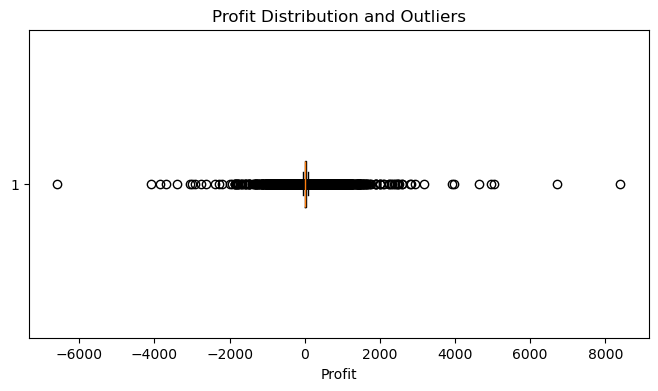

In [58]:
plt.figure(figsize=(8,4))

plt.boxplot(
    df["profit"].dropna(),
    vert=False
)

plt.title("Profit Distribution and Outliers")
plt.xlabel("Profit")

plt.show()

In [59]:
print("STATISTICAL ANALYSIS SUMMARY")
print("-" * 45)

print(f"Pearson Correlation: {r:.4f}")
print(f"Pearson P-value: {p_value:.3e}")

print(f"\nANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA P-value: {anova_p:.3e}")

print(f"\nKruskal-Wallis P-value: {kruskal_p:.3e}")

print(f"\nEta Squared: {eta_squared:.4f}")
print(f"Variance Explained: {eta_squared * 100:.2f}%")

print(f"\nLoss-making Orders: {loss_count}")
print(f"Loss-making Order %: {loss_percentage:.2f}%")

STATISTICAL ANALYSIS SUMMARY
---------------------------------------------
Pearson Correlation: -0.8464
Pearson P-value: 0.000e+00

ANOVA F-statistic: 31053.5898
ANOVA P-value: 0.000e+00

Kruskal-Wallis P-value: 0.000e+00

Eta Squared: 0.7517
Variance Explained: 75.17%

Loss-making Orders: 12544
Loss-making Order %: 24.46%


In [68]:
print("BUSINESS CONCLUSION")
print("-" * 45)

if r < 0 and p_value < 0.05:
    print("• Higher discounts are significantly associated with lower profit margins.")

if welch_result.pvalue < 0.05:
    print("• Profit margins differ significantly across discount bands (Welch's ANOVA).")

if kruskal_p < 0.05:
    print("• The difference remains significant using the non-parametric Kruskal-Wallis test.")

print(
    f"• Discount bands show a very large association with profit-margin differences "
    f"(η² = {eta_squared:.4f})."
)

print(
    f"• {loss_percentage:.2f}% of transactions are loss-making."
)

print(
    "• High-discount and extreme-loss transactions should be prioritized "
    "for profit-leakage investigation."
)

BUSINESS CONCLUSION
---------------------------------------------
• Higher discounts are significantly associated with lower profit margins.
• Profit margins differ significantly across discount bands (Welch's ANOVA).
• The difference remains significant using the non-parametric Kruskal-Wallis test.
• Discount bands show a very large association with profit-margin differences (η² = 0.7517).
• 24.46% of transactions are loss-making.
• High-discount and extreme-loss transactions should be prioritized for profit-leakage investigation.


In [61]:
print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
  group1     group2    meandiff p-adj   lower     upper   reject
----------------------------------------------------------------
    0-10%      10-20%   -3.3709   0.0   -4.6514   -2.0903   True
    0-10%      20-30%  -20.9862   0.0  -23.3281  -18.6444   True
    0-10%      30-50%  -50.9218   0.0  -52.2061  -49.6374   True
    0-10%   Above 50%  -132.142   0.0 -133.5536 -130.7303   True
    0-10% No Discount    9.3497   0.0    8.3052   10.3941   True
   10-20%      20-30%  -17.6154   0.0  -19.9057   -15.325   True
   10-20%      30-50%  -47.5509   0.0  -48.7386  -46.3632   True
   10-20%   Above 50% -128.7711   0.0 -130.0955 -127.4467   True
   10-20% No Discount   12.7205   0.0   11.7975   13.6436   True
   20-30%      30-50%  -29.9355   0.0   -32.228  -27.6431   True
   20-30%   Above 50% -111.1557   0.0 -113.5219 -108.7896   True
   20-30% No Discount   30.3359   0.0   28.1687   32.5031   True
   30-50%   Above 50%  -8

In [70]:
print("Welch's ANOVA")
print("-------------------------")
print("Statistic:", round(welch_result.statistic, 4))

if welch_result.pvalue < 0.001:
    print("P-value: < 0.001")
else:
    print("P-value:", round(welch_result.pvalue, 4))

Welch's ANOVA
-------------------------
Statistic: 11077.2888
P-value: < 0.001


## Business Recommendations

In [71]:
print("KEY BUSINESS FINDINGS")
print("=" * 50)

print("\n1. DISCOUNT & PROFITABILITY")
print(f"   Correlation: {r:.4f}")
print("   Higher discounts are strongly associated with lower profit margins.")

print("\n2. STATISTICAL SIGNIFICANCE")
print("   Welch's ANOVA: p < 0.001")
print("   Profit margins differ significantly across discount bands.")

print("\n3. EFFECT SIZE")
print(f"   Eta Squared: {eta_squared:.4f}")
print(f"   Discount bands show a very large association with profit-margin differences.")

print("\n4. LOSS-MAKING TRANSACTIONS")
print(f"   Loss-making transactions: {loss_count:,}")
print(f"   Loss-making rate: {loss_percentage:.2f}%")

print("\n5. HIGH-DISCOUNT RISK")
print(f"   High-discount loss transactions: {len(high_discount_loss):,}")
print(
    f"   Share of loss-making transactions: "
    f"{len(high_discount_loss) / loss_count * 100:.2f}%"
)

print("\n6. EXTREME DISCOUNT BAND")
print("   Above 50% discount has the lowest average profit margin.")

KEY BUSINESS FINDINGS

1. DISCOUNT & PROFITABILITY
   Correlation: -0.8464
   Higher discounts are strongly associated with lower profit margins.

2. STATISTICAL SIGNIFICANCE
   Welch's ANOVA: p < 0.001
   Profit margins differ significantly across discount bands.

3. EFFECT SIZE
   Eta Squared: 0.7517
   Discount bands show a very large association with profit-margin differences.

4. LOSS-MAKING TRANSACTIONS
   Loss-making transactions: 12,544
   Loss-making rate: 24.46%

5. HIGH-DISCOUNT RISK
   High-discount loss transactions: 9,579
   Share of loss-making transactions: 76.36%

6. EXTREME DISCOUNT BAND
   Above 50% discount has the lowest average profit margin.


## Business Recommendations

### 1. Review High Discounting
Review high-discount transactions before approving similar promotions, as higher discounts are strongly associated with lower profit margins.

### 2. Control Extreme Discounts
Transactions with discounts above 50% should receive additional review because this discount band has the lowest average profit margin.

### 3. Investigate Loss-Making Transactions
Investigate the 24.46% of transactions that are loss-making to identify recurring product, customer, market, or discount-related patterns.

### 4. Prioritize High-Discount Losses
Prioritize loss-making transactions with discounts above 30% for profit-leakage investigation.

### 5. Evaluate Promotions Using Profitability
Evaluate promotional performance using profit and profit margin, rather than relying only on sales or revenue growth.

### 6. Establish Discount Controls
Use the statistical evidence to support discount thresholds, approval rules, and ongoing monitoring of promotion profitability.